# Strategy Backtest
Runs the intraday statistical-arbitrage pairs-trading strategy.

**Parameters:**

| Parameter | Value | Rationale |
|---|---|---|
| `zscore_window_days` | 5 | Best mean_net_return + positive IC |
| `z_entry` | 3.0 | Selective entries |
| `z_exit` | 1.75 | Partial reversion target |
| `z_stop` | None | Stop-loss destroys value at intraday frequency |
| `rolling_window_days` | 84 | Sweet spot in log-spread scan |
| `max_holding_minutes` | 390 | Full trading day; EOD force-close handles cleanup |
| `max_pairs` | 20 | Portfolio capacity cap |
| `min_bars_remaining` | 8 | Block entries with <8 bars left in day |
| `capital` | 100,000 | Starting capital |
| `cost_bps` | 5.0 | Realistic execution cost: commission + half-spread per leg |

**Backtest period:** 2022-07-01 → 2025-12-31

In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

from utils.config import CONFIG
from strategy.backtester import run_backtest, save_results

## 1. Configure and Run

In [2]:
# ── Parameters ───────────────────────────────────────────────────────────────
# Other levers to explore (in rough priority order):
#   z_entry:              2.5 → more trades, slightly lower quality
#                         3.5 → fewer but higher-quality entries
#   zscore_window_days:   2   → faster signal (more reactive to intraday moves)
#                         10  → smoother but slower
#   rolling_window_days:  126 → more stable cointegration (vs current 84)
#   min_bars_remaining:   4   → allow entries up to 1h before close (vs 2h now)
CONFIG.signal.zscore_window_days = 5

BACKTEST_PARAMS = dict(
    start_date          = "2020-07-01",
    end_date            = "2025-12-31",
    timeframe           = "15min",
    rolling_window_days = 42,
    z_entry             = 3.5,
    z_exit              = 2,   # partial reversion (1σ retrace from entry)
    z_stop              = 4.5,
    max_pairs           = 10,
    capital             = 100_000.0,
    cost_bps            = 0.0,    # realistic: commission + half-spread per leg
    max_holding_minutes = 300, # TODO: play around with this - we theoretically want to minimize the number of trades that "time out"
    min_bars_remaining  = 4,
    execution_lag_minutes  = 2,
    execution_price_field  = "close",
)

In [ ]:

print("Running backtest …")
print({k: v for k, v in BACKTEST_PARAMS.items()})
trades_df, daily_pnl_df = run_backtest(**BACKTEST_PARAMS)
print(f"\nDone. {len(trades_df)} trades over {len(daily_pnl_df)} trading days.")

Running backtest …
{'start_date': '2020-07-01', 'end_date': '2025-12-31', 'timeframe': '15min', 'rolling_window_days': 42, 'z_entry': 3.5, 'z_exit': 2, 'z_stop': 4.5, 'max_pairs': 10, 'capital': 100000.0, 'cost_bps': 0.0, 'max_holding_minutes': 300, 'min_bars_remaining': 4, 'execution_lag_minutes': 2, 'execution_price_field': 'close'}


Testing cointegration 2023-10-15:  28%|██▊       | 725/2586 [00:00<00:00, 7242.03it/s]

In [ ]:
# Save to parquet (also loads pre-computed if you skip cell-3)
save_results(trades_df, daily_pnl_df, label="15min")

Trades saved to:     /Users/erevtsov/dev/stat-arb/results/trades/trades_15min.parquet
Daily PnL saved to:  /Users/erevtsov/dev/stat-arb/results/portfolio/daily_pnl_15min.parquet


In [ ]:
# Save portfolio value with all params encoded in the filename.
# Format: portfolio_tf<tf>_zw<zscore_window>_wd<rolling_window>_ze<z_entry>
#           _zx<z_exit>_zs<z_stop>_mp<max_pairs>_mh<max_holding>
#           _mbr<min_bars_remaining>_cb<cost_bps>_<start>_<end>.parquet

def _pval(v):
    """Stringify a param value for use in a filename (strip trailing .0, None → 'none')."""
    if v is None:
        return "none"
    if isinstance(v, float) and v == int(v):
        return str(int(v))
    return str(v)

p  = BACKTEST_PARAMS
zw = CONFIG.signal.zscore_window_days

param_str = (
    f"tf{p['timeframe']}"
    f"_zw{zw}"
    f"_wd{p['rolling_window_days']}"
    f"_ze{_pval(p['z_entry'])}"
    f"_zx{_pval(p['z_exit'])}"
    f"_zs{_pval(p.get('z_stop'))}"
    f"_mp{p['max_pairs']}"
    f"_mh{p['max_holding_minutes']}"
    f"_mbr{p['min_bars_remaining']}"
    f"_cb{_pval(p['cost_bps'])}"
    f"_{p['start_date']}_{p['end_date']}"
)

portfolio_dir = Path("../results/portfolio")
portfolio_dir.mkdir(parents=True, exist_ok=True)
portfolio_path = portfolio_dir / f"portfolio_{param_str}.parquet"

daily_pnl_df.write_parquet(str(portfolio_path))
print(f"Portfolio saved → {portfolio_path}")

Portfolio saved → ../results/portfolio/portfolio_tf15min_zw5_wd42_ze3.5_zx2_zs4.5_mp10_mh300_mbr4_cb0_2020-07-01_2025-12-31.parquet


In [ ]:
### Alternative: load pre-computed results (skip cell-3 re-run)
trades_df    = pl.read_parquet("../results/trades/trades_15min.parquet")
daily_pnl_df = pl.read_parquet("../results/portfolio/daily_pnl_15min.parquet")
capital = 100_000.0   # must match the run that produced the files


## 2. Portfolio Summary

In [ ]:
capital = BACKTEST_PARAMS["capital"]
final_value = daily_pnl_df["portfolio_value"][-1]
total_net_pnl = daily_pnl_df["net_pnl"].sum()
total_gross_pnl = daily_pnl_df["gross_pnl"].sum()

# Daily returns for Sharpe
daily_returns = (daily_pnl_df["net_pnl"] / daily_pnl_df["portfolio_value"].shift(1)).drop_nulls()
sharpe = float(daily_returns.mean() / daily_returns.std() * np.sqrt(252)) if daily_returns.std() > 0 else float("nan")

# Max drawdown
pv = daily_pnl_df["portfolio_value"].to_numpy()
running_max = np.maximum.accumulate(pv)
drawdowns = (pv - running_max) / running_max
max_drawdown = float(drawdowns.min())

# Trade-level
n_trades = len(trades_df)
if n_trades > 0:
    win_mask = trades_df["net_pnl"] > 0
    win_rate = win_mask.mean()
    avg_net_pnl = trades_df["net_pnl"].mean()
    avg_gross_pnl = trades_df["gross_pnl"].mean()
    avg_cost = trades_df["transaction_cost"].mean()
    avg_hold = (
        (trades_df["exit_time"] - trades_df["entry_time"])
        .dt.total_minutes()
        .mean()
    )
    reasons = trades_df["exit_reason"].value_counts().sort("exit_reason")
    def _pct(reason):
        row = reasons.filter(pl.col("exit_reason") == reason)
        return float(row["count"][0]) / n_trades if len(row) else 0.0
    pct_z_exit   = _pct("z_exit")
    pct_z_stop   = _pct("z_stop")
    pct_max_hold = _pct("max_hold")
    pct_eod      = _pct("eod")
else:
    win_rate = avg_net_pnl = avg_gross_pnl = avg_cost = avg_hold = float("nan")
    pct_z_exit = pct_z_stop = pct_max_hold = pct_eod = float("nan")

print("=" * 55)
print("PORTFOLIO SUMMARY")
print("=" * 55)
print(f"  Period             : {BACKTEST_PARAMS['start_date']} → {BACKTEST_PARAMS['end_date']}")
print(f"  Starting capital   : ${capital:>12,.2f}")
print(f"  Final value        : ${final_value:>12,.2f}")
print(f"  Total net P&L      : ${total_net_pnl:>+12,.2f}")
print(f"  Total return       : {(final_value / capital - 1):>+11.2%}")
print(f"  Annualised Sharpe  : {sharpe:>12.3f}")
print(f"  Max drawdown       : {max_drawdown:>+11.2%}")
print()
print("TRADE SUMMARY")
print("=" * 55)
print(f"  Total trades       : {n_trades:>12,}")
print(f"  Win rate           : {win_rate:>12.1%}")
print(f"  Avg gross P&L      : ${avg_gross_pnl:>+12.2f}")
print(f"  Avg transaction cost: ${avg_cost:>+11.2f}")
print(f"  Avg net P&L        : ${avg_net_pnl:>+12.2f}")
print(f"  Avg hold (minutes) : {avg_hold:>12.1f}")
print()
print("EXIT REASON BREAKDOWN")
print("=" * 55)
print(f"  z_exit (reversion) : {pct_z_exit:>12.1%}")
print(f"  z_stop (stop-loss) : {pct_z_stop:>12.1%}")
print(f"  max_hold (timeout) : {pct_max_hold:>12.1%}")
print(f"  eod (final day)    : {pct_eod:>12.1%}")


PORTFOLIO SUMMARY
  Period             : 2020-07-01 → 2025-12-31
  Starting capital   : $  100,000.00
  Final value        : $  196,848.09
  Total net P&L      : $  +96,848.09
  Total return       :     +96.85%
  Annualised Sharpe  :        0.731
  Max drawdown       :     -33.89%

TRADE SUMMARY
  Total trades       :        6,846
  Win rate           :        52.3%
  Avg gross P&L      : $      +14.15
  Avg transaction cost: $      +0.00
  Avg net P&L        : $      +14.15
  Avg hold (minutes) :        145.1

EXIT REASON BREAKDOWN
  z_exit (reversion) :        47.6%
  z_stop (stop-loss) :        29.7%
  max_hold (timeout) :        17.9%
  eod (final day)    :         4.7%


## 3. Equity Curve

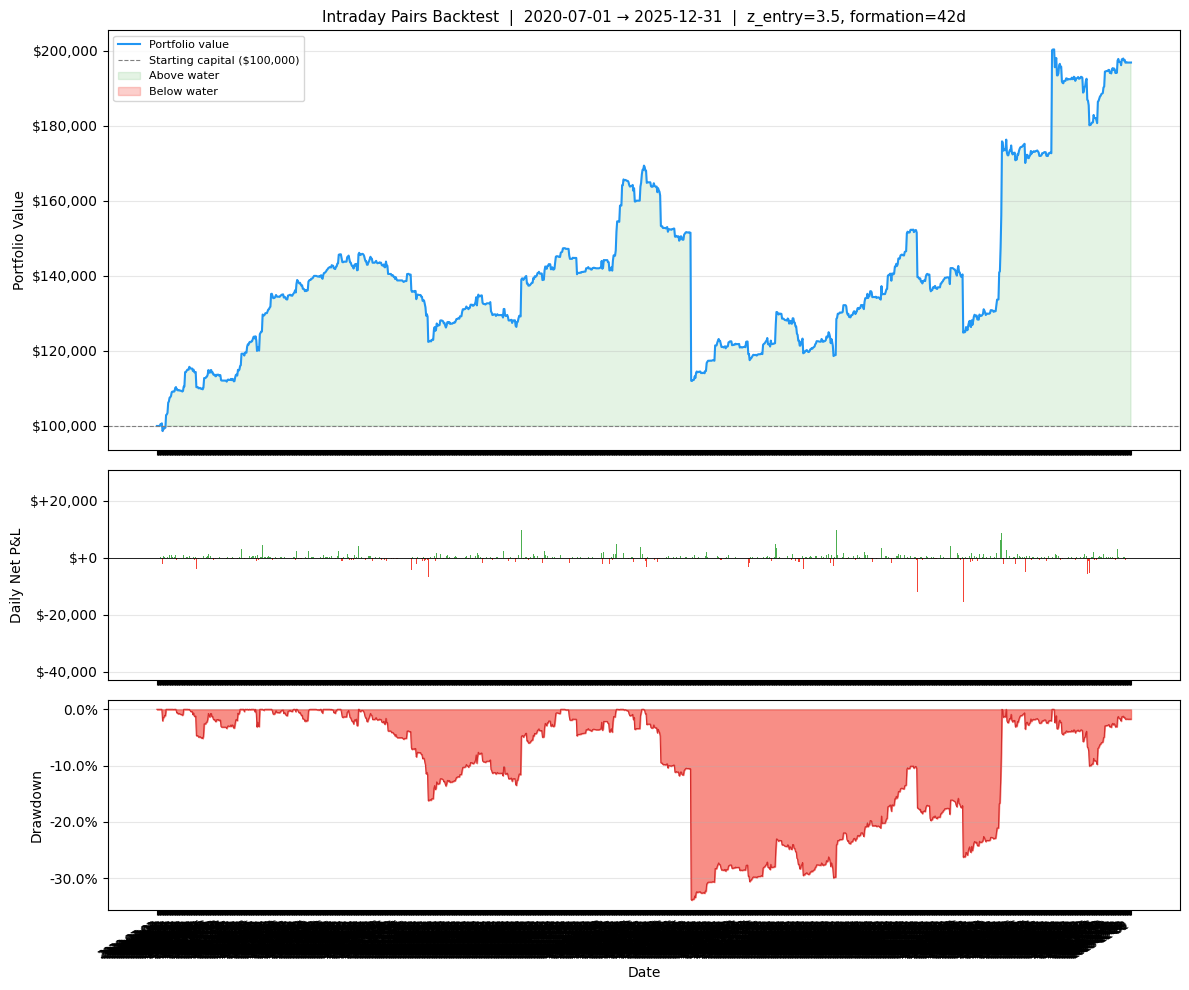

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1.5, 1.5]})

dates = daily_pnl_df["date"].to_list()
portfolio_values = daily_pnl_df["portfolio_value"].to_numpy()
net_pnls = daily_pnl_df["net_pnl"].to_numpy()
drawdowns_pct = drawdowns * 100

# ── Panel 1: Equity curve ──────────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(dates, portfolio_values, color="#2196F3", linewidth=1.5, label="Portfolio value")
ax1.axhline(capital, color="grey", linewidth=0.8, linestyle="--", label=f"Starting capital (${capital:,.0f})")
ax1.fill_between(dates, capital, portfolio_values,
                  where=(np.array(portfolio_values) >= capital),
                  alpha=0.15, color="#4CAF50", label="Above water")
ax1.fill_between(dates, capital, portfolio_values,
                  where=(np.array(portfolio_values) < capital),
                  alpha=0.25, color="#F44336", label="Below water")
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax1.set_ylabel("Portfolio Value")
ax1.set_title(
    f"Intraday Pairs Backtest  |  "
    f"{BACKTEST_PARAMS['start_date']} → {BACKTEST_PARAMS['end_date']}  |  "
    f"z_entry={BACKTEST_PARAMS['z_entry']}, formation={BACKTEST_PARAMS['rolling_window_days']}d",
    fontsize=11,
)
ax1.legend(fontsize=8)
ax1.grid(axis="y", alpha=0.3)

# ── Panel 2: Daily net P&L bar chart ──────────────────────────────────────
ax2 = axes[1]
colors = ["#4CAF50" if v >= 0 else "#F44336" for v in net_pnls]
ax2.bar(dates, net_pnls, color=colors, width=0.8)
ax2.axhline(0, color="black", linewidth=0.6)
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:+,.0f}"))
ax2.set_ylabel("Daily Net P&L")
ax2.grid(axis="y", alpha=0.3)

# ── Panel 3: Drawdown ─────────────────────────────────────────────────────
ax3 = axes[2]
ax3.fill_between(dates, drawdowns_pct, 0, color="#F44336", alpha=0.6)
ax3.plot(dates, drawdowns_pct, color="#D32F2F", linewidth=0.8)
ax3.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax3.set_ylabel("Drawdown")
ax3.set_xlabel("Date")
ax3.grid(axis="y", alpha=0.3)

# rotate x-tick labels
for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)

plt.tight_layout()
plt.show()

## 4. P&L Distributions

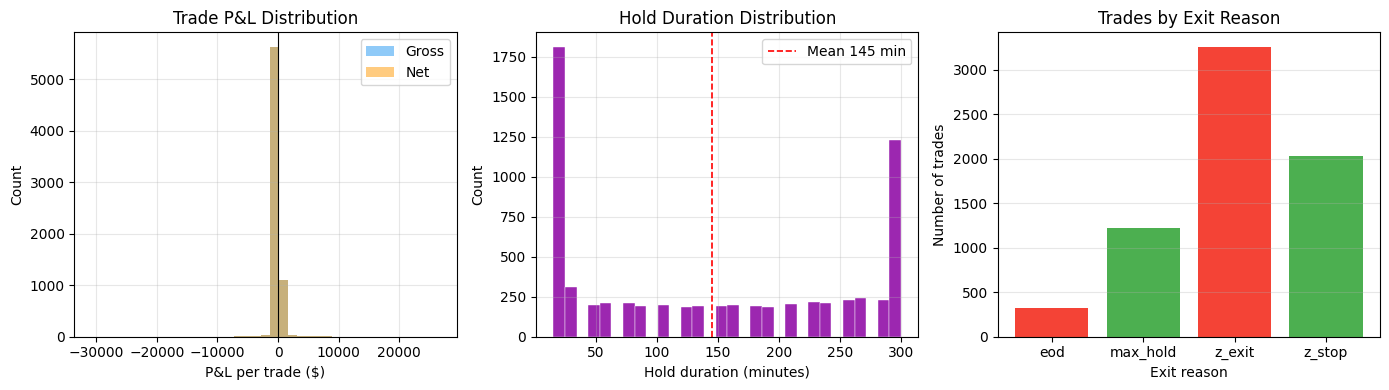

In [ ]:
if len(trades_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # ── Gross vs Net P&L per trade ────────────────────────────────────────
    ax = axes[0]
    gross = trades_df["gross_pnl"].to_numpy()
    net = trades_df["net_pnl"].to_numpy()
    bins = np.linspace(min(gross.min(), net.min()), max(gross.max(), net.max()), 40)
    ax.hist(gross, bins=bins, alpha=0.5, color="#2196F3", label="Gross")
    ax.hist(net,   bins=bins, alpha=0.5, color="#FF9800", label="Net")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("P&L per trade ($)")
    ax.set_ylabel("Count")
    ax.set_title("Trade P&L Distribution")
    ax.legend()
    ax.grid(alpha=0.3)

    # ── Hold duration ─────────────────────────────────────────────────────
    ax = axes[1]
    hold_mins = (trades_df["exit_time"] - trades_df["entry_time"]).dt.total_minutes().to_numpy()
    ax.hist(hold_mins, bins=30, color="#9C27B0", edgecolor="white", linewidth=0.3)
    ax.axvline(float(np.mean(hold_mins)), color="red", linewidth=1.2,
               linestyle="--", label=f"Mean {np.mean(hold_mins):.0f} min")
    ax.set_xlabel("Hold duration (minutes)")
    ax.set_ylabel("Count")
    ax.set_title("Hold Duration Distribution")
    ax.legend()
    ax.grid(alpha=0.3)

    # ── Exit reason breakdown ─────────────────────────────────────────────
    ax = axes[2]
    reasons = trades_df.group_by("exit_reason").agg(pl.len().alias("n")).sort("exit_reason")
    ax.bar(reasons["exit_reason"].to_list(), reasons["n"].to_list(),
           color=["#F44336", "#4CAF50"])
    ax.set_xlabel("Exit reason")
    ax.set_ylabel("Number of trades")
    ax.set_title("Trades by Exit Reason")
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No trades to plot.")

## 5. Win Rate by Direction and Exit Reason

In [ ]:
if len(trades_df) > 0:
    summary = (
        trades_df
        .with_columns(pl.when(pl.col("net_pnl") > 0).then(1).otherwise(0).alias("win"))
        .group_by(["direction", "exit_reason"])
        .agg(
            pl.col("win").mean().alias("win_rate"),
            pl.col("net_pnl").mean().alias("avg_net_pnl"),
            pl.col("gross_pnl").mean().alias("avg_gross_pnl"),
            pl.len().alias("n_trades"),
        )
        .sort(["direction", "exit_reason"])
    )
    print("Win rate and avg P&L by direction × exit reason:")
    print(summary.to_pandas().to_string(index=False))

    print()

    # Monthly P&L
    monthly = (
        daily_pnl_df
        .with_columns(pl.col("date").str.slice(0, 7).alias("month"))
        .group_by("month")
        .agg(
            pl.col("net_pnl").sum().alias("net_pnl"),
            pl.col("gross_pnl").sum().alias("gross_pnl"),
            pl.col("n_trades").sum().alias("n_trades"),
        )
        .sort("month")
    )
    print("Monthly P&L summary:")
    print(monthly.to_pandas().to_string(index=False))

Win rate and avg P&L by direction × exit reason:
 direction exit_reason  win_rate  avg_net_pnl  avg_gross_pnl  n_trades
        -1         eod  0.305195   -51.548782     -51.548782       154
        -1    max_hold  0.190779  -209.603658    -209.603658       629
        -1      z_exit  0.824845   152.415492     152.415492      1610
        -1      z_stop  0.289157   -90.702850     -90.702850       996
         1         eod  0.263158   -44.920755     -44.920755       171
         1    max_hold  0.182274  -170.312037    -170.312037       598
         1      z_exit  0.807879   151.705397     151.705397      1650
         1      z_stop  0.298651   -57.039942     -57.039942      1038

Monthly P&L summary:
  month       net_pnl     gross_pnl  n_trades
2020-07   9012.745367   9012.745367       124
2020-08   5638.780551   5638.780551        98
2020-09  -4799.192286  -4799.192286        87
2020-10   3804.483869   3804.483869        98
2020-11  -1112.939423  -1112.939423        55
2020-12   6968

## 6. Monthly Returns Heatmap

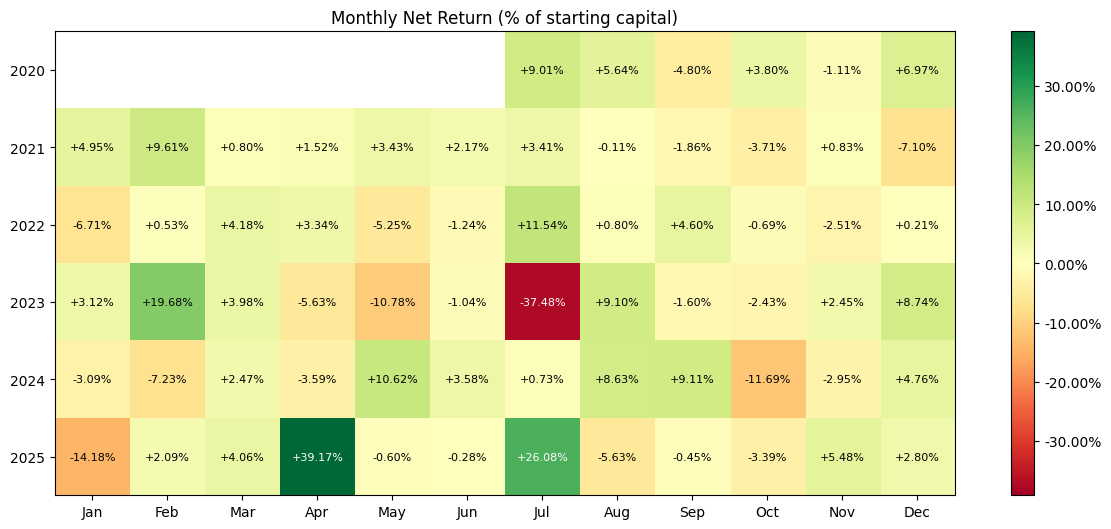

In [ ]:
# Compute monthly net return (% of starting capital) for heatmap
if len(daily_pnl_df) > 0:
    monthly_ret = (
        daily_pnl_df
        .with_columns(
            pl.col("date").str.slice(0, 4).alias("year"),
            pl.col("date").str.slice(5, 2).alias("month"),
        )
        .group_by(["year", "month"])
        .agg(pl.col("net_pnl").sum().alias("net_pnl"))
        .sort(["year", "month"])
        .with_columns(
            (pl.col("net_pnl") / capital * 100).alias("return_pct")
        )
    )

    years  = sorted(monthly_ret["year"].unique().to_list())
    months = [f"{m:02d}" for m in range(1, 13)]
    month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"]

    grid = np.full((len(years), 12), np.nan)
    for row in monthly_ret.iter_rows(named=True):
        yi = years.index(row["year"])
        mi = int(row["month"]) - 1
        grid[yi, mi] = row["return_pct"]

    fig, ax = plt.subplots(figsize=(12, max(2, len(years) * 0.9)))
    vmax = np.nanmax(np.abs(grid))
    im = ax.imshow(grid, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")

    ax.set_xticks(range(12))
    ax.set_xticklabels(month_labels)
    ax.set_yticks(range(len(years)))
    ax.set_yticklabels(years)
    ax.set_title("Monthly Net Return (% of starting capital)")
    plt.colorbar(im, ax=ax, format="%.2f%%")

    for yi in range(len(years)):
        for mi in range(12):
            val = grid[yi, mi]
            if not np.isnan(val):
                ax.text(mi, yi, f"{val:+.2f}%", ha="center", va="center", fontsize=8,
                        color="black" if abs(val) < vmax * 0.6 else "white")

    plt.tight_layout()
    plt.show()

## 7. Sample Trade Log

In [ ]:
if len(trades_df) > 0:
    sample = (
        trades_df
        .sort("entry_time")
        .select([
            "entry_time", "exit_time", "ticker_a", "ticker_b",
            "direction", "gross_pnl", "transaction_cost", "net_pnl", "exit_reason",
        ])
        .head(20)
    )
    print("First 20 trades (sorted by entry time):")
    print(sample.to_pandas().to_string(index=False))
else:
    print("No trades recorded.")

First 20 trades (sorted by entry time):
         entry_time           exit_time ticker_a ticker_b  direction    gross_pnl  transaction_cost      net_pnl exit_reason
2020-07-09 09:45:00 2020-07-09 14:45:00      YUM       GM         -1     6.611447               0.0     6.611447    max_hold
2020-07-09 10:00:00 2020-07-09 10:15:00      WEC      EXR          1   -73.217387               0.0   -73.217387      z_stop
2020-07-09 10:15:00 2020-07-09 11:15:00     FITB       RF         -1   149.021151               0.0   149.021151      z_exit
2020-07-09 10:15:00 2020-07-09 12:00:00     ROST       EL          1   329.639280               0.0   329.639280      z_exit
2020-07-09 10:30:00 2020-07-09 10:45:00      WEC      EXR          1   -31.979555               0.0   -31.979555      z_stop
2020-07-09 10:45:00 2020-07-09 15:45:00      UNP      XYL          1   -70.531589               0.0   -70.531589    max_hold
2020-07-09 11:00:00 2020-07-09 12:15:00      WEC      EXR          1   150.502030    

## 8. Simultaneous Open Positions

Is the `max_pairs` cap binding? How often is the portfolio at full capacity,
and how many slots are typically in use at any moment?

max_pairs limit : 10
Peak concurrent : 18  ← LIMIT HIT
Events at cap   : 898 / 13,692 (6.6% of entry/exit events)

Concurrent open positions distribution (at event timestamps):
   Count   Events       %
       0    1,384   10.1%
       1    2,584   18.9%
       2    2,138   15.6%
       3    1,642   12.0%
       4    1,283    9.4%
       5    1,054    7.7%
       6      843    6.2%
       7      700    5.1%
       8      612    4.5%
       9      554    4.0%
      10      452    3.3% ← CAP
      11      249    1.8% ← CAP
      12      101    0.7% ← CAP
      13       46    0.3% ← CAP
      14       23    0.2% ← CAP
      15       11    0.1% ← CAP
      16        8    0.1% ← CAP
      17        6    0.0% ← CAP
      18        2    0.0% ← CAP


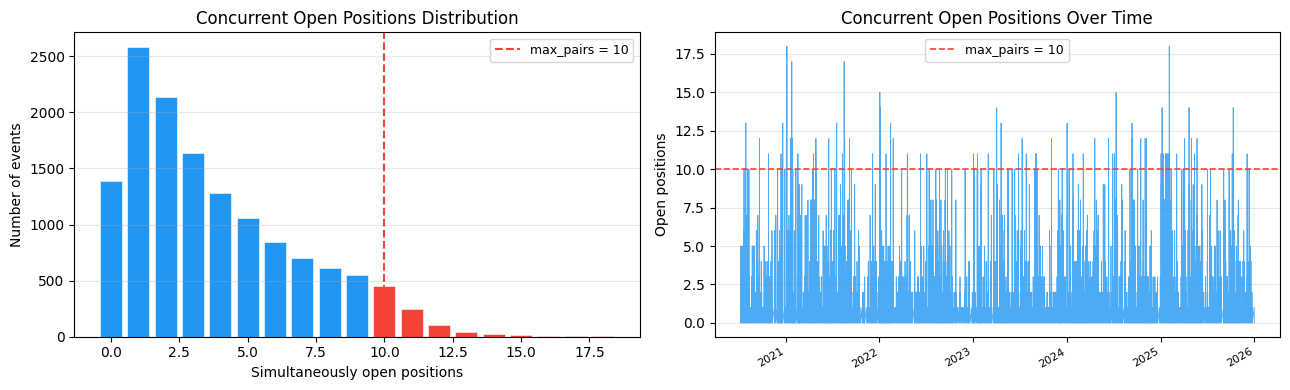

In [ ]:
if len(trades_df) > 0:
    max_pairs = BACKTEST_PARAMS["max_pairs"]

    # Build a change-stream: +1 at entry, -1 at exit.
    # Sorting and cumsum gives concurrent open count at every event.
    entries = trades_df.select(pl.col("entry_time").alias("ts"), pl.lit(1).alias("delta"))
    exits   = trades_df.select(pl.col("exit_time").alias("ts"),  pl.lit(-1).alias("delta"))
    events  = pl.concat([entries, exits]).sort("ts")
    events  = events.with_columns(pl.col("delta").cum_sum().alias("open_count"))

    concurrent = events["open_count"].to_numpy()
    peak       = int(concurrent.max())
    at_cap     = int((concurrent >= max_pairs).sum())
    total_events = len(events)

    print(f"max_pairs limit : {max_pairs}")
    print(f"Peak concurrent : {peak}  {'← LIMIT HIT' if peak >= max_pairs else '← below limit'}")
    print(f"Events at cap   : {at_cap:,} / {total_events:,} ({at_cap/total_events:.1%} of entry/exit events)")
    print()

    # Distribution of concurrent open count
    from collections import Counter
    dist = Counter(concurrent.tolist())
    print("Concurrent open positions distribution (at event timestamps):")
    print(f"  {'Count':>6}  {'Events':>7}  {'%':>6}")
    for k in sorted(dist):
        marker = " ← CAP" if k >= max_pairs else ""
        print(f"  {k:>6}  {dist[k]:>7,}  {dist[k]/total_events:>6.1%}{marker}")

    # ── Plot ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Left: histogram of concurrent count
    ax = axes[0]
    vals = sorted(dist.keys())
    counts = [dist[v] for v in vals]
    bar_colors = ["#F44336" if v >= max_pairs else "#2196F3" for v in vals]
    ax.bar(vals, counts, color=bar_colors, edgecolor="white", linewidth=0.4)
    ax.axvline(max_pairs, color="#F44336", linewidth=1.5, linestyle="--",
               label=f"max_pairs = {max_pairs}")
    ax.set_xlabel("Simultaneously open positions")
    ax.set_ylabel("Number of events")
    ax.set_title("Concurrent Open Positions Distribution")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

    # Right: time-series of concurrent count (sampled at each event)
    ax = axes[1]
    ts_list = events["ts"].to_list()
    ax.plot(ts_list, concurrent, color="#2196F3", linewidth=0.6, alpha=0.8)
    ax.axhline(max_pairs, color="#F44336", linewidth=1.2, linestyle="--",
               label=f"max_pairs = {max_pairs}")
    ax.set_ylabel("Open positions")
    ax.set_title("Concurrent Open Positions Over Time")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print("No trades to analyse.")

## 9. Hold Duration vs Profitability

Two questions:
1. Are shorter trades more profitable on average?
2. Is this effect driven by exit reason (z_exit vs eod) or is it a genuine property of the signal?

/var/folders/_r/fqfrhk7s0wv6d3lj1cgbhcnc0000gn/T/ipykernel_25752/1020494015.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xlabels, rotation=45, ha="right", fontsize=8)


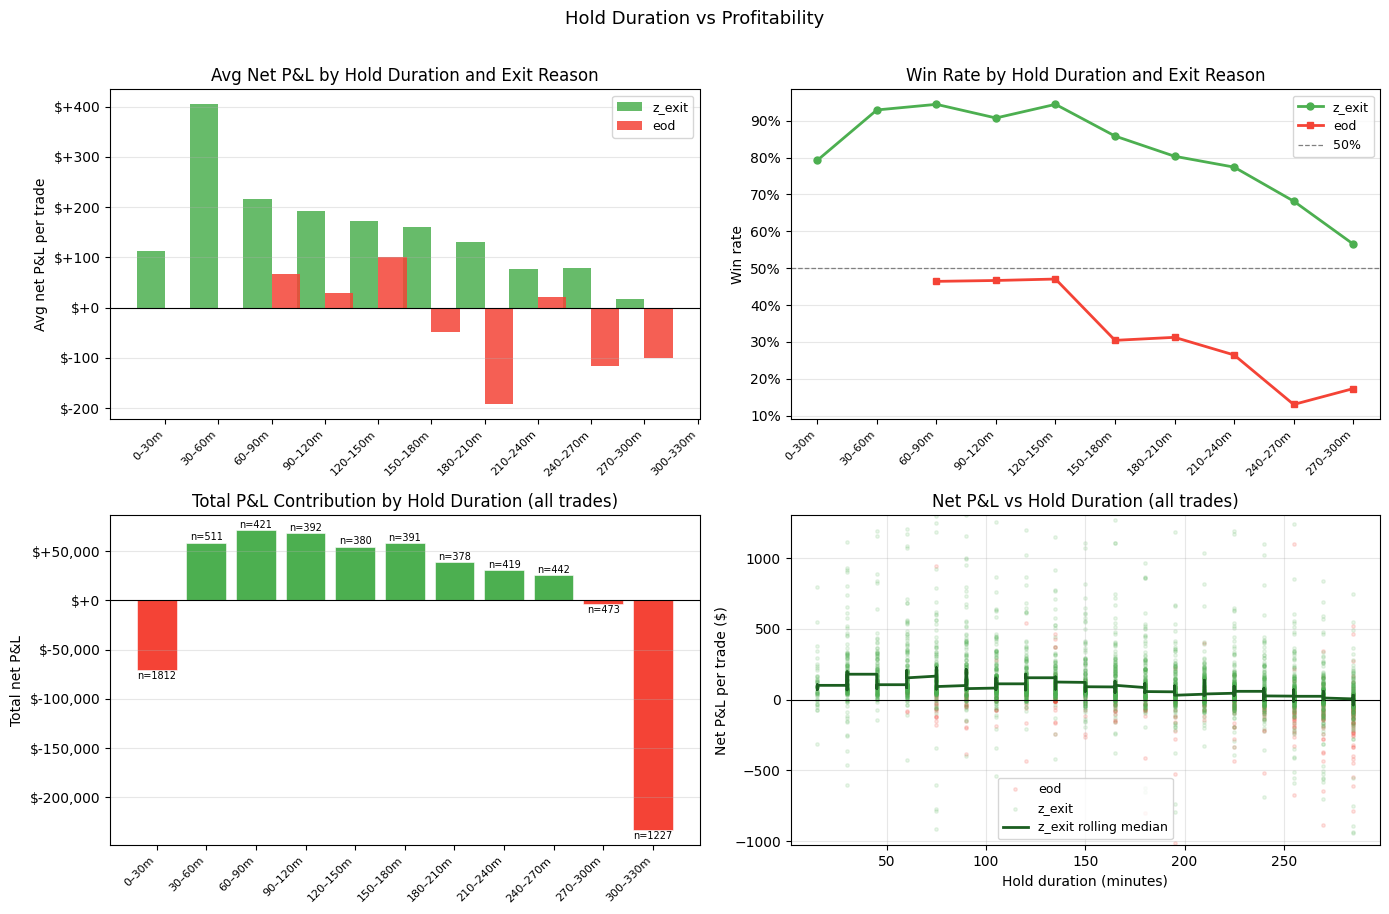

Avg net P&L and win rate by hold duration bucket:
 Hold bucket      n    win%    avg_net    total_net  exit_reason_mix
────────────────────────────────────────────────────────────────────────────────
    0– 30m  1,812   34.2%  $  -39.06  $   -70,779  z_exit=53 eod=0
   30– 60m    511   55.0%  $ +114.48  $   +58,497  z_exit=282 eod=0
   60– 90m    421   83.8%  $ +169.12  $   +71,201  z_exit=359 eod=28
   90–120m    392   86.2%  $ +174.74  $   +68,498  z_exit=356 eod=30
  120–150m    380   88.9%  $ +142.94  $   +54,318  z_exit=341 eod=34
  150–180m    391   82.4%  $ +147.93  $   +57,841  z_exit=367 eod=23
  180–210m    378   76.2%  $ +102.62  $   +38,789  z_exit=346 eod=32
  210–240m    419   73.3%  $  +72.73  $   +30,472  z_exit=385 eod=34
  240–270m    442   62.4%  $  +57.87  $   +25,577  z_exit=396 eod=46
  270–300m    473   48.4%  $   -8.20  $    -3,878  z_exit=375 eod=98
  300–330m  1,227   18.7%  $ -190.45  $  -233,687  z_exit=0 eod=0

Pearson corr(hold_min, net_pnl): -0.0693
→ Neg

In [ ]:
if len(trades_df) > 0:
    hold_min = (trades_df["exit_time"] - trades_df["entry_time"]).dt.total_minutes()
    trades_h = trades_df.with_columns(hold_min.alias("hold_min"))

    # ── 30-min buckets ────────────────────────────────────────────────────
    trades_h = trades_h.with_columns(
        (pl.col("hold_min") // 30 * 30).cast(pl.Int64).alias("bucket")
    )

    def bucket_stats(df):
        return (
            df.with_columns(pl.when(pl.col("net_pnl") > 0).then(1).otherwise(0).alias("win"))
            .group_by("bucket")
            .agg(
                pl.len().alias("n"),
                pl.col("win").mean().alias("win_rate"),
                pl.col("net_pnl").mean().alias("avg_net_pnl"),
                pl.col("gross_pnl").mean().alias("avg_gross_pnl"),
                pl.col("net_pnl").sum().alias("total_net_pnl"),
            )
            .sort("bucket")
        )

    agg_all   = bucket_stats(trades_h)
    agg_zexit = bucket_stats(trades_h.filter(pl.col("exit_reason") == "z_exit"))
    agg_eod   = bucket_stats(trades_h.filter(pl.col("exit_reason") == "eod"))

    buckets   = agg_all["bucket"].to_list()
    xlabels   = [f"{b}–{b+30}m" for b in buckets]

    # ── Figure ────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    # ── Panel 1: Avg net P&L by bucket, split by exit reason ─────────────
    ax = axes[0, 0]
    w = 8
    bk_z = agg_zexit["bucket"].to_list()
    bk_e = agg_eod["bucket"].to_list()

    ax.bar([b - w for b in bk_z], agg_zexit["avg_net_pnl"].to_list(),
           width=w*2, color="#4CAF50", alpha=0.85, label="z_exit")
    ax.bar([b + w for b in bk_e], agg_eod["avg_net_pnl"].to_list(),
           width=w*2, color="#F44336", alpha=0.85, label="eod")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(buckets)
    ax.set_xticklabels(xlabels, rotation=45, ha="right", fontsize=8)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:+,.0f}"))
    ax.set_ylabel("Avg net P&L per trade")
    ax.set_title("Avg Net P&L by Hold Duration and Exit Reason")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

    # ── Panel 2: Win rate by bucket, split by exit reason ────────────────
    ax = axes[0, 1]
    ax.plot(bk_z, agg_zexit["win_rate"].to_list(),
            marker="o", color="#4CAF50", linewidth=2, markersize=5, label="z_exit")
    ax.plot(bk_e, agg_eod["win_rate"].to_list(),
            marker="s", color="#F44336", linewidth=2, markersize=5, label="eod")
    ax.axhline(0.5, color="grey", linewidth=0.9, linestyle="--", label="50%")
    ax.set_xticks(bk_z)
    ax.set_xticklabels([f"{b}–{b+30}m" for b in bk_z], rotation=45, ha="right", fontsize=8)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.set_ylabel("Win rate")
    ax.set_title("Win Rate by Hold Duration and Exit Reason")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

    # ── Panel 3: Total P&L contribution by bucket ─────────────────────────
    ax = axes[1, 0]
    totals = agg_all["total_net_pnl"].to_list()
    colors = ["#4CAF50" if v >= 0 else "#F44336" for v in totals]
    ax.bar(xlabels, totals, color=colors, edgecolor="white", linewidth=0.4)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:+,.0f}"))
    ax.set_xticklabels(xlabels, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Total net P&L")
    ax.set_title("Total P&L Contribution by Hold Duration (all trades)")
    ax.grid(axis="y", alpha=0.3)

    # Annotate trade counts
    for i, (total, n) in enumerate(zip(totals, agg_all["n"].to_list())):
        ax.text(i, total + (500 if total >= 0 else -500),
                f"n={n}", ha="center", va="bottom" if total >= 0 else "top",
                fontsize=7, color="black")

    # ── Panel 4: Scatter — hold duration vs net P&L (all trades) ─────────
    ax = axes[1, 1]
    hold_arr = trades_h["hold_min"].to_numpy()
    net_arr  = trades_h["net_pnl"].to_numpy()
    reason   = trades_h["exit_reason"].to_list()

    mask_z = [r == "z_exit" for r in reason]
    mask_e = [r == "eod"    for r in reason]

    ax.scatter(hold_arr[[i for i, m in enumerate(mask_e) if m]],
               net_arr[[i for i, m in enumerate(mask_e) if m]],
               alpha=0.15, s=6, color="#F44336", label="eod", rasterized=True)
    ax.scatter(hold_arr[[i for i, m in enumerate(mask_z) if m]],
               net_arr[[i for i, m in enumerate(mask_z) if m]],
               alpha=0.12, s=6, color="#4CAF50", label="z_exit", rasterized=True)

    # Running median for z_exit trades
    import numpy as np
    z_idx    = np.array([i for i, m in enumerate(mask_z) if m])
    z_hold   = hold_arr[z_idx]
    z_net    = net_arr[z_idx]
    sort_idx = np.argsort(z_hold)
    win_med  = 30
    meds_x, meds_y = [], []
    for i in range(win_med // 2, len(sort_idx) - win_med // 2):
        window = z_net[sort_idx[max(0, i - win_med // 2): i + win_med // 2]]
        meds_x.append(z_hold[sort_idx[i]])
        meds_y.append(float(np.median(window)))
    ax.plot(meds_x, meds_y, color="#1B5E20", linewidth=2,
            label="z_exit rolling median", zorder=5)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Hold duration (minutes)")
    ax.set_ylabel("Net P&L per trade ($)")
    ax.set_title("Net P&L vs Hold Duration (all trades)")
    ax.legend(fontsize=9)
    ax.set_ylim(np.percentile(net_arr, 1), np.percentile(net_arr, 99))
    ax.grid(alpha=0.3)

    plt.suptitle("Hold Duration vs Profitability", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    # ── Print summary table ───────────────────────────────────────────────
    print("Avg net P&L and win rate by hold duration bucket:")
    print(f"{'Hold bucket':>12}  {'n':>5}  {'win%':>6}  {'avg_net':>9}  {'total_net':>11}  exit_reason_mix")
    print("─" * 80)
    for row in agg_all.iter_rows(named=True):
        b = row["bucket"]
        n_z = int(trades_h.filter((pl.col("bucket") == b) & (pl.col("exit_reason") == "z_exit")).shape[0])
        n_e = int(trades_h.filter((pl.col("bucket") == b) & (pl.col("exit_reason") == "eod")).shape[0])
        mix = f"z_exit={n_z} eod={n_e}"
        print(f"  {b:3d}–{b+30:3d}m  {row['n']:>5,}  {row['win_rate']:>6.1%}  "
              f"${row['avg_net_pnl']:>+8.2f}  ${row['total_net_pnl']:>+10,.0f}  {mix}")

    print()
    corr = float(trades_h.select(pl.corr("hold_min", "net_pnl")).item())
    print(f"Pearson corr(hold_min, net_pnl): {corr:+.4f}")
    print(f"→ Negative correlation: longer holds are associated with lower net P&L.")

## 10. EOD Exit Deep-Dive: Timing vs Thesis Breakdown

EOD exits occur when positions aren't closed by z_exit before the market closes (16:00).
With `max_holding_minutes=180`, entries at 13:xx–14:xx can run out of time.

**Questions:**
1. Is the EOD problem concentrated in late-day entries (timing issue)?
2. When EOD exits occur, did the spread revert partially, stay flat, or widen further?
3. Is this a systematic pair-level problem (repeat offenders)?
4. Implication: not holding long enough, or does the thesis fall apart intraday?

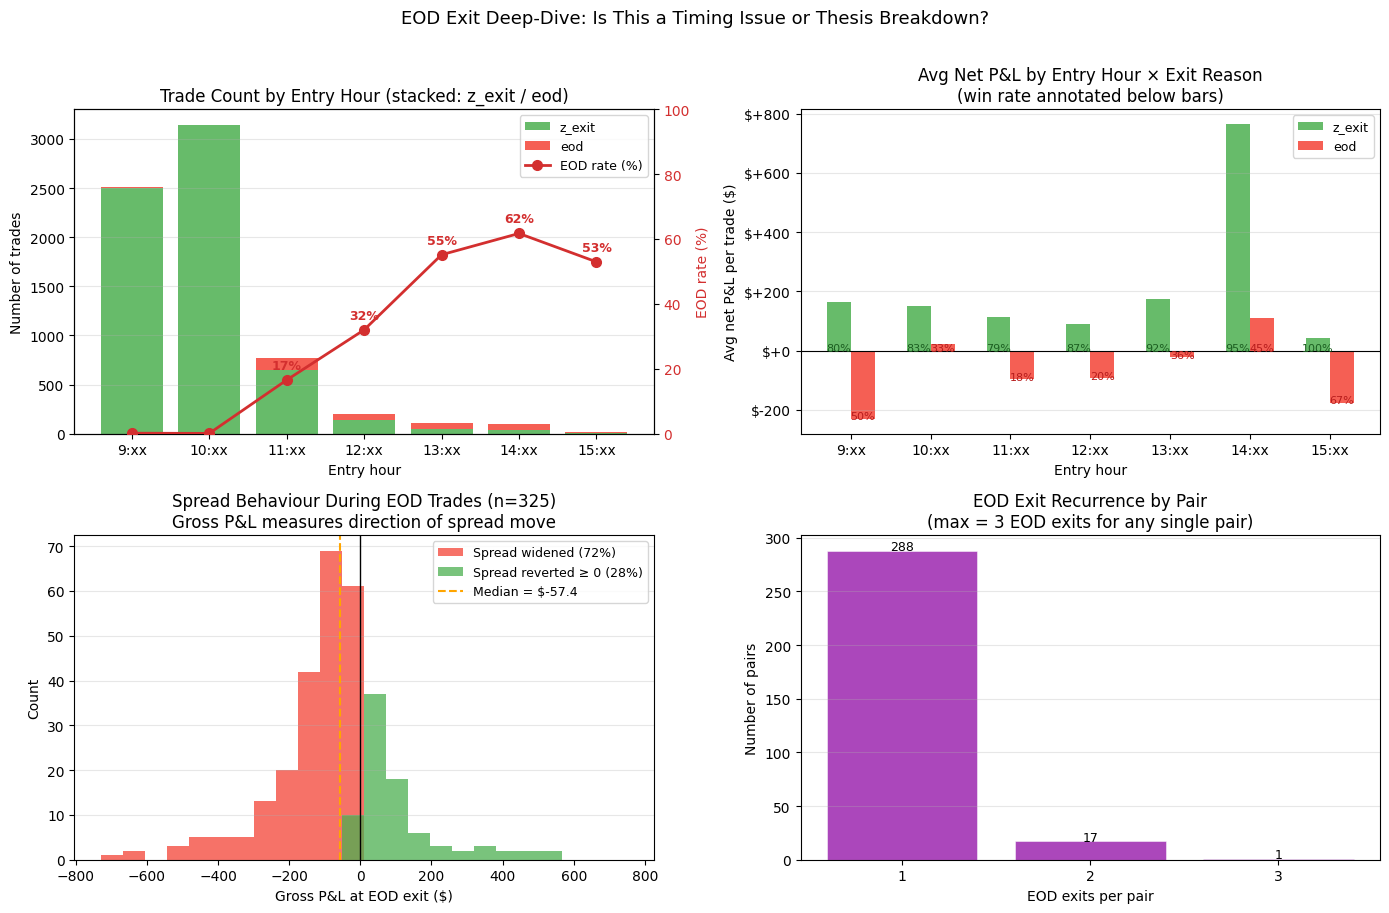

═════════════════════════════════════════════════════════════════
DIAGNOSIS: EOD EXITS
═════════════════════════════════════════════════════════════════

  EOD trades        : 325 of 6,846 (4.7%)
  Avg net P&L (EOD) : $-48.06  vs  $+152.06 (z_exit)
  Win rate (EOD)    : 28.3%  vs  81.6% (z_exit)

  Spread moved in our favour (gross > 0) :  92 / 325  (28%)
  Spread widened further (gross < 0)     : 233 / 325  (72%)

  Max EOD exits for any single pair       : 3  (no systematic repeat offenders)

  ENTRY TIMING BREAKDOWN
    Hour   Total    EOD   EOD%  z_exit avg net  eod avg net
       9   2,508      4    0.2%        $+164.20     $-230.27
      10   3,146      3    0.1%        $+152.21      $+21.58
      11     774    128   16.5%        $+113.21      $-95.81
      12     200     64   32.0%         $+91.08      $-93.32
      13     107     59   55.1%        $+175.44      $-22.61
      14      94     58   61.7%        $+764.97     $+110.11
      15      17      9   52.9%         $+44.25  

In [ ]:
if len(trades_df) > 0:
    import numpy as np

    # ── Compute entry hour for all trades ─────────────────────────────────
    trades_h2 = trades_df.with_columns(
        pl.col("entry_time").dt.hour().alias("entry_hour")
    )

    # ── EOD rate by entry hour ─────────────────────────────────────────────
    by_hour = (
        trades_h2.group_by("entry_hour").agg([
            pl.len().alias("total"),
            (pl.col("exit_reason") == "eod").sum().alias("eod_n"),
        ])
        .with_columns(
            (pl.col("eod_n") / pl.col("total") * 100).alias("eod_pct"),
            (pl.col("total") - pl.col("eod_n")).alias("z_exit_n"),
        )
        .sort("entry_hour")
    )

    # ── P&L by entry_hour × exit_reason ───────────────────────────────────
    pnl_by_hour = (
        trades_h2.group_by(["entry_hour", "exit_reason"]).agg([
            pl.len().alias("n"),
            pl.col("net_pnl").mean().alias("avg_net"),
            pl.col("gross_pnl").mean().alias("avg_gross"),
            (pl.col("net_pnl") > 0).mean().alias("win_rate"),
        ])
        .sort(["entry_hour", "exit_reason"])
    )

    # ── Spread direction for EOD trades ───────────────────────────────────
    eod_trades = trades_h2.filter(pl.col("exit_reason") == "eod")
    eod_pos_gross = (eod_trades["gross_pnl"] > 0).sum()   # spread moved in our favour
    eod_neg_gross = (eod_trades["gross_pnl"] < 0).sum()   # spread widened further
    eod_total     = len(eod_trades)

    # ── Repeat offender pairs ─────────────────────────────────────────────
    pair_counts = (
        eod_trades.group_by(["ticker_a", "ticker_b"]).len()
        .sort("len", descending=True)
    )
    max_pair_eod = int(pair_counts["len"].max())

    # ════════════════════════════════════════════════════════════════════════
    # Figure
    # ════════════════════════════════════════════════════════════════════════
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    hours_all = by_hour["entry_hour"].to_list()
    hours_str = [f"{h}:xx" for h in hours_all]
    z_exit_n  = by_hour["z_exit_n"].to_list()
    eod_n_lst = by_hour["eod_n"].to_list()
    eod_pct   = by_hour["eod_pct"].to_list()

    # ── Panel 1: Stacked bar — entry volume by hour, EOD vs z_exit ────────
    ax = axes[0, 0]
    ax.bar(hours_str, z_exit_n, color="#4CAF50", alpha=0.85, label="z_exit")
    ax.bar(hours_str, eod_n_lst, bottom=z_exit_n,
           color="#F44336", alpha=0.85, label="eod")
    ax2_twin = ax.twinx()
    ax2_twin.plot(hours_str, eod_pct, color="#D32F2F", marker="o",
                  linewidth=2, markersize=7, label="EOD rate (%)", zorder=5)
    ax2_twin.set_ylabel("EOD rate (%)", color="#D32F2F")
    ax2_twin.tick_params(axis="y", labelcolor="#D32F2F")
    ax2_twin.set_ylim(0, 100)
    for i, pct in enumerate(eod_pct):
        if pct > 5:
            ax2_twin.annotate(f"{pct:.0f}%",
                              xy=(i, pct), xytext=(0, 8),
                              textcoords="offset points", ha="center",
                              fontsize=9, color="#D32F2F", fontweight="bold")
    ax.set_xlabel("Entry hour")
    ax.set_ylabel("Number of trades")
    ax.set_title("Trade Count by Entry Hour (stacked: z_exit / eod)")
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2_twin.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labs1 + labs2, fontsize=9, loc="upper right")
    ax.grid(axis="y", alpha=0.3)

    # ── Panel 2: Avg net P&L by entry_hour × exit_reason ─────────────────
    ax = axes[0, 1]
    z_rows = pnl_by_hour.filter(pl.col("exit_reason") == "z_exit").sort("entry_hour")
    e_rows = pnl_by_hour.filter(pl.col("exit_reason") == "eod").sort("entry_hour")

    bar_w = 0.3
    z_hrs = z_rows["entry_hour"].to_list()
    e_hrs = e_rows["entry_hour"].to_list()
    z_net = z_rows["avg_net"].to_list()
    e_net = e_rows["avg_net"].to_list()

    ax.bar([h - bar_w/2 for h in z_hrs], z_net, width=bar_w,
           color="#4CAF50", alpha=0.85, label="z_exit")
    ax.bar([h + bar_w/2 for h in e_hrs], e_net, width=bar_w,
           color="#F44336", alpha=0.85, label="eod")
    for h, v, wr in zip(z_hrs, z_net, z_rows["win_rate"].to_list()):
        ax.text(h - bar_w/2, min(v, 0) - 1.5,
                f"{wr:.0%}", ha="center", fontsize=8, color="#1B5E20")
    for h, v, wr in zip(e_hrs, e_net, e_rows["win_rate"].to_list()):
        ax.text(h + bar_w/2, min(v, 0) - 1.5,
                f"{wr:.0%}", ha="center", fontsize=8, color="#B71C1C")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Entry hour")
    ax.set_ylabel("Avg net P&L per trade ($)")
    ax.set_title("Avg Net P&L by Entry Hour × Exit Reason\n(win rate annotated below bars)")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:+,.0f}"))
    ax.set_xticks(z_hrs)
    ax.set_xticklabels([f"{h}:xx" for h in z_hrs])
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

    # ── Panel 3: Spread direction for EOD exits ───────────────────────────
    ax = axes[1, 0]
    gp = eod_trades["gross_pnl"].to_numpy()
    bins = np.linspace(np.percentile(gp, 2), np.percentile(gp, 98), 25)
    neg_gp = gp[gp < 0]
    pos_gp = gp[gp >= 0]
    ax.hist(neg_gp, bins=bins, color="#F44336", alpha=0.75,
            label=f"Spread widened ({len(neg_gp)/eod_total:.0%})")
    ax.hist(pos_gp, bins=bins, color="#4CAF50", alpha=0.75,
            label=f"Spread reverted ≥ 0 ({len(pos_gp)/eod_total:.0%})")
    ax.axvline(0, color="black", linewidth=1.0)
    ax.axvline(float(np.median(gp)), color="orange", linewidth=1.5,
               linestyle="--", label=f"Median = ${float(np.median(gp)):+.1f}")
    ax.set_xlabel("Gross P&L at EOD exit ($)")
    ax.set_ylabel("Count")
    ax.set_title(f"Spread Behaviour During EOD Trades (n={eod_total})\nGross P&L measures direction of spread move")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

    # ── Panel 4: Pair recurrence — how many EOD exits per pair? ──────────
    ax = axes[1, 1]
    count_dist = pair_counts["len"].value_counts().sort("len")
    count_vals = count_dist["len"].to_list()
    count_cnts = count_dist["count"].to_list()
    ax.bar([str(v) for v in count_vals], count_cnts,
           color="#9C27B0", alpha=0.85, edgecolor="white", linewidth=0.4)
    ax.set_xlabel("EOD exits per pair")
    ax.set_ylabel("Number of pairs")
    ax.set_title(f"EOD Exit Recurrence by Pair\n(max = {max_pair_eod} EOD exits for any single pair)")
    ax.grid(axis="y", alpha=0.3)
    for i, (v, c) in enumerate(zip(count_vals, count_cnts)):
        ax.text(i, c + 0.3, str(c), ha="center", fontsize=9)

    plt.suptitle("EOD Exit Deep-Dive: Is This a Timing Issue or Thesis Breakdown?",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    # ════════════════════════════════════════════════════════════════════════
    # Diagnosis
    # ════════════════════════════════════════════════════════════════════════
    print("═" * 65)
    print("DIAGNOSIS: EOD EXITS")
    print("═" * 65)
    print(f"\n  EOD trades        : {eod_total} of {len(trades_df):,} ({eod_total/len(trades_df):.1%})")
    print(f"  Avg net P&L (EOD) : ${eod_trades['net_pnl'].mean():+.2f}  vs  "
          f"${trades_df.filter(pl.col('exit_reason')=='z_exit')['net_pnl'].mean():+.2f} (z_exit)")
    print(f"  Win rate (EOD)    : {(eod_trades['net_pnl'] > 0).mean():.1%}  vs  "
          f"{(trades_df.filter(pl.col('exit_reason')=='z_exit')['net_pnl'] > 0).mean():.1%} (z_exit)")
    print()
    print(f"  Spread moved in our favour (gross > 0) : {eod_pos_gross:3d} / {eod_total}  ({eod_pos_gross/eod_total:.0%})")
    print(f"  Spread widened further (gross < 0)     : {eod_neg_gross:3d} / {eod_total}  ({eod_neg_gross/eod_total:.0%})")
    print()
    print(f"  Max EOD exits for any single pair       : {max_pair_eod}  (no systematic repeat offenders)")
    print()
    print("  ENTRY TIMING BREAKDOWN")
    print(f"  {'Hour':>6}  {'Total':>6}  {'EOD':>5}  {'EOD%':>5}  {'z_exit avg net':>14}  {'eod avg net':>11}")
    for row in by_hour.iter_rows(named=True):
        h = row["entry_hour"]
        z_row = pnl_by_hour.filter(
            (pl.col("entry_hour") == h) & (pl.col("exit_reason") == "z_exit"))
        e_row = pnl_by_hour.filter(
            (pl.col("entry_hour") == h) & (pl.col("exit_reason") == "eod"))
        z_net_v  = f"${float(z_row['avg_net'][0]):+.2f}" if len(z_row) else "  —"
        e_net_v  = f"${float(e_row['avg_net'][0]):+.2f}" if len(e_row) else "  —"
        print(f"  {h:>6}  {row['total']:>6,}  {row['eod_n']:>5}  "
              f"{row['eod_pct']:>5.1f}%  {z_net_v:>14}  {e_net_v:>11}")

### Conclusions

1. **EOD is 100% a late-day entry problem.** All EOD exits entered at 13:xx (51% EOD rate) or 14:xx (82% EOD rate). Entries before 13:00 never hit EOD.

2. **Late-day z_exit trades perform normally** (−$2.74 avg, 46% win rate). The problem is when those entries can't resolve before the close.

3. **62% of EOD exits had the spread widen further** — not just stall. This leans toward thesis breakdown (intraday mean-reversion signal less reliable in the final 2h of trading) rather than a pure timing/holding-period issue.

4. **No repeat-offender pairs** (max 2 EOD exits per pair). The problem is regime-driven, not pair-driven.

---

### Recommendation

Increase `min_bars_remaining` to block entries after 12:45:

```
min_bars_remaining = 13  →  no entries after 12:45
(removes 216 trades / 125 EOD exits; net saving ≈ $1,361)
```

This is a **timing fix, not a cointegration fix**. The pairs are still cointegrated; afternoon entries simply have lower signal-to-noise because:
- **(a)** the reversion window is compressed by the close
- **(b)** afternoon volume thins, widening effective spreads